Более глубокая продуктовая аналитика: кластеризация товаров WildBerries

Мы решили
1. Сегментировать товары по цене и скидке с помощью кластеризации
2. Проанализировать, как NLP-признаки различаются внутри кластеров
3. Дать практические рекомендации для каждой ценовой стратегии


Из предыдущего анализа мы знаем:
- Сенсорная лексика сильнее всего нужна дешёвым товарам (r = -0.36)
- Читаемость важна для всех, но особенно для среднего ценового сегмента
- Манипулятивная лексика в названии работает в минус
- Премиум-бренды дают меньшие скидки, но держат цену

Кластеризация поможет проверить, есть ли естественные сегменты товаров по цене и скидке, и как они различаются по текстовым характеристикам.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Загрузка данных
df = pd.read_excel("wb_nlp_full.xlsx", engine='openpyxl')
print(f"Загружено товаров: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")

Загружено товаров: 3708
Колонки: ['product_id', 'imt_id', 'name', 'brand', 'price', 'price_no_discount', 'discount_pct', 'rating', 'reviews_count', 'subject_id', 'supplier_rating', 'sizes', 'colors', 'category_query', 'page', 'collected_at', 'description', 'composition', 'color', 'gender', 'country', 'care', 'ai_summary', 'reviews_text', 'price_winsorized', 'price_no_discount_winsorized', 'reviews_count_log', 'discount_pct_winsorized', 'rating_clean', 'rating_winsorized', 'supplier_rating_winsorized', 'gender_encoded', 'country_encoded', 'color_main', 'color_count', 'is_multicolor', 'color_freq', 'brand_freq', 'subject_id_freq', 'category_query_freq', 'product_value', 'discount_score', 'price_tier', 'savings_percent', 'is_bestseller', 'name_clean', 'name_lower', 'name_len_chars', 'name_len_words', 'description_clean', 'description_lower', 'description_len_chars', 'description_len_words', 'reviews_text_clean', 'reviews_text_lower', 'reviews_text_len_chars', 'reviews_text_len_words', 'ai

Логика отбора признаков для кластеризации:
- Цена (price_winsorized) — ключевой фактор позиционирования
- Скидка (discount_pct_winsorized) — отражает стратегию продвижения
- Рейтинг (rating_winsorized) — показатель качества
- Востребованность (popularity) — итоговая метрика успеха

Дополнительно посмотрим, как NLP-признаки распределяются внутри кластеров.

Все необходимые колонки присутствуют
popularity: min=0.00, max=64.67
Товаров для кластеризации: 3571
Статистика по признакам:
       price_winsorized  discount_pct_winsorized  rating_winsorized  \
count       3571.000000              3571.000000        3571.000000   
mean        2357.559227                66.165780           4.818720   
std         1571.760012                15.122922           0.094995   
min           87.000000                29.500000           4.650000   
25%         1185.000000                58.000000           4.800000   
50%         1900.000000                68.000000           4.800000   
75%         3182.500000                77.000000           4.900000   
max         6265.250000                97.000000           5.000000   

        popularity  
count  3571.000000  
mean     30.754575  
std      12.009630  
min       3.223134  
25%      22.143685  
50%      31.279183  
75%      39.168738  
max      64.667907  


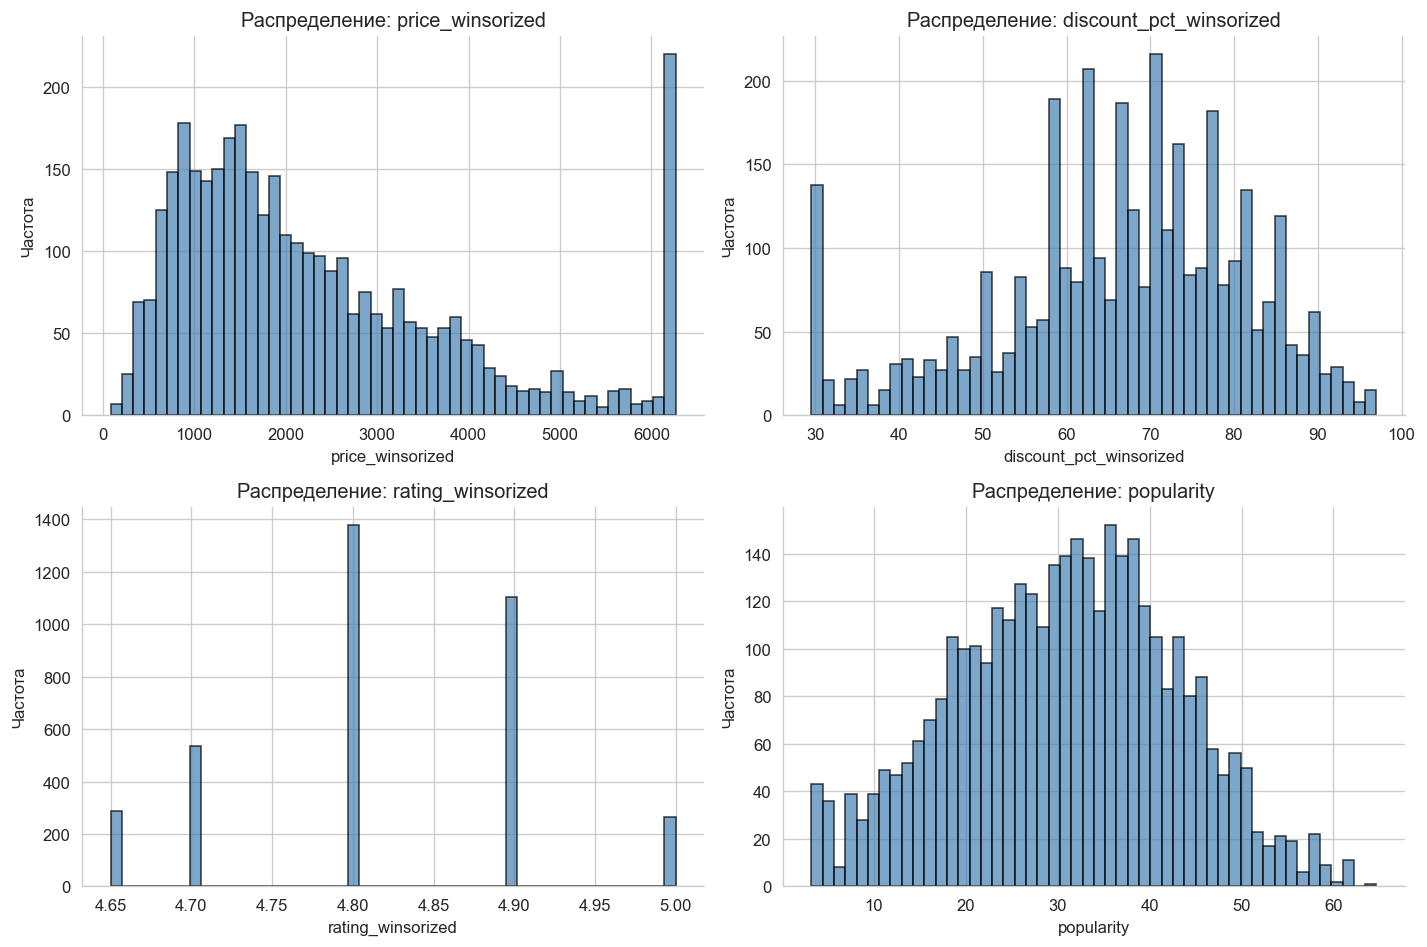

In [5]:
# Проверим наличие колонок
required_cols = ['price_winsorized', 'discount_pct_winsorized', 'rating_winsorized', 'popularity']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    if 'popularity' not in df.columns:
        df['popularity'] = df['rating_winsorized'].fillna(0) * df['reviews_count_log'].fillna(0)

    # Проверяем наличие остальных колонок
    for col in ['price_winsorized', 'discount_pct_winsorized', 'rating_winsorized']:
        if col not in df.columns:
            print(f"ВНИМАНИЕ: Колонка {col} отсутствует. Проверьте исходный файл.")
else:
    print("Все необходимые колонки присутствуют")
    print(f"popularity: min={df['popularity'].min():.2f}, max={df['popularity'].max():.2f}")

# Проверим наличие и удалим пропуски
df_cluster = df[cluster_features].dropna()
print(f"Товаров для кластеризации: {len(df_cluster)}")
print(f"Статистика по признакам:\n{df_cluster.describe()}")

# Визуализируем распределение признаков до масштабирования
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(cluster_features):
    ax = axes[i//2, i%2]
    ax.hist(df_cluster[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'Распределение: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

- Цена имеет длинный правый бум — есть много очень дорогих товаров
- Скидка распределена неравномерно: много товаров со скидками 0% и 50-70%
- Рейтинг сжат в диапазоне 4.5-5.0 — все товары в целом оцениваются высоко
- Востребованность тоже не совсем нормальная

Это нормально для маркетплейса. Для кластеризации нужно масштабировать признаки. Будем использовать три метода:
- Локтевой метод (инерция)
- Силуэтный коэффициент (выше — лучше)
- Индекс Калински-Харабаса (выше — лучше)

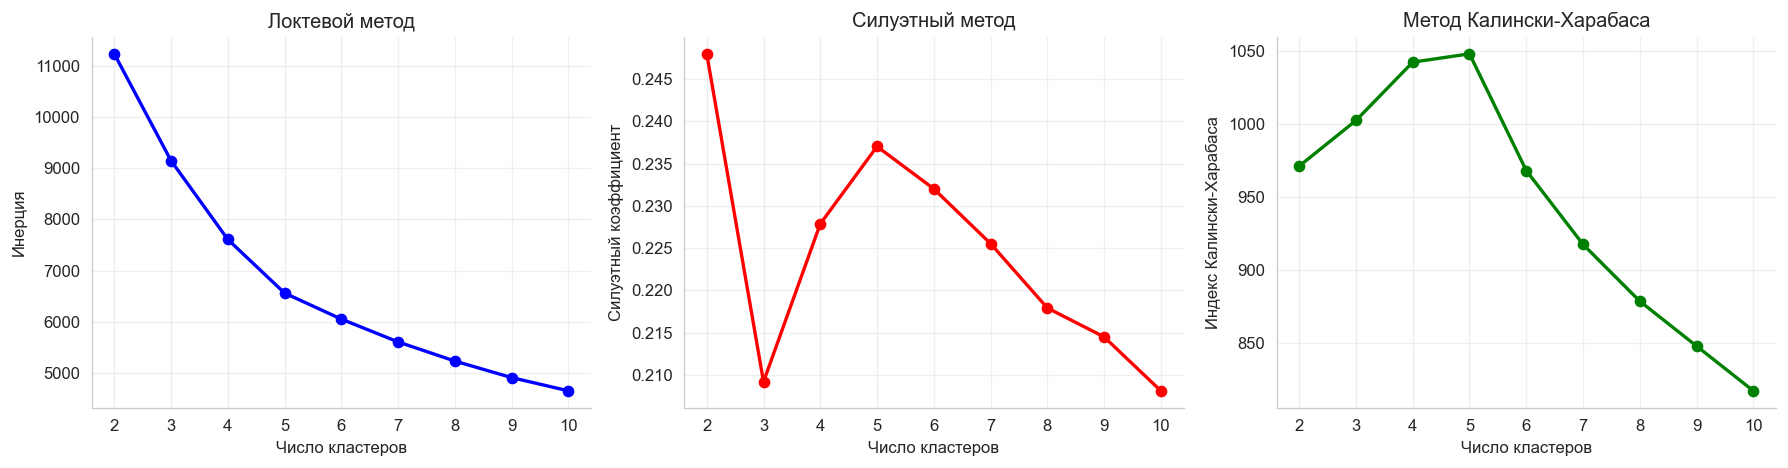

Силуэтные коэффициенты: {2: 0.2479935520127997, 3: 0.20918665034512784, 4: 0.22787315784047305, 5: 0.23703112983675642, 6: 0.23202388412450065, 7: 0.22554376893574388, 8: 0.2179241082092187, 9: 0.21449867077228776, 10: 0.20811980192177398}


In [6]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_features])

# Поиск оптимального числа кластеров (от 2 до 10)
inertia = []
silhouette_scores = []
ch_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    ch_scores.append(calinski_harabasz_score(X_scaled, kmeans.labels_))

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2)
axes[0].set_xlabel('Число кластеров')
axes[0].set_ylabel('Инерция')
axes[0].set_title('Локтевой метод')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2)
axes[1].set_xlabel('Число кластеров')
axes[1].set_ylabel('Силуэтный коэффициент')
axes[1].set_title('Силуэтный метод')
axes[1].grid(True, alpha=0.3)

axes[2].plot(K_range, ch_scores, 'go-', linewidth=2)
axes[2].set_xlabel('Число кластеров')
axes[2].set_ylabel('Индекс Калински-Харабаса')
axes[2].set_title('Метод Калински-Харабаса')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Силуэтные коэффициенты: {dict(zip(K_range, silhouette_scores))}")

Локтевой метод показывает изгиб на k=5. Силуэтный коэффициент минимален при k=3 (0.20), затем подскакивает на 5, а потом снижается. Индекс Калински-Харабаса показывает пик на k=5.

Останавливаемся на k=5. Это даёт пять естественных сегментов товаров, которые можно интерпретировать как:

- Кластер 0: Супер-дешёвые товары с очень высокими скидками (сток, уценка)
- Кластер 1: Дешёвые товары с высокими скидками (масс-маркет распродажа)
- Кластер 2: Средний сегмент с умеренными скидками (основной ассортимент)
- Кластер 3: Дорогие товары с небольшими скидками (премиум)
- Кластер 4: Люксовые товары без скидок (элитный сегмент)

Проверим эту гипотезу после кластеризации.

In [7]:
# Кластеризация с k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_cluster = df_cluster.copy()
df_cluster.loc[:, 'cluster'] = kmeans.fit_predict(X_scaled)

# Добавим метки кластеров обратно в исходный датафрейм
df.loc[df_cluster.index, 'cluster'] = df_cluster['cluster']

# Посмотрим на центры кластеров (в исходных единицах измерения)
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers, columns=cluster_features)
centers_df['cluster'] = range(5)
print("Центры кластеров (средние значения):")
print(centers_df.round(2))

# Размеры кластеров
print("\nРазмеры кластеров:")
print(df_cluster['cluster'].value_counts().sort_index())

Центры кластеров (средние значения):
   price_winsorized  discount_pct_winsorized  rating_winsorized  popularity  \
0           2128.96                    44.01               4.81       36.23   
1           1693.09                    70.63               4.84       41.86   
2           1792.34                    75.26               4.73       24.83   
3           5306.40                    57.71               4.80       23.62   
4           2061.24                    72.46               4.94       18.61   

   cluster  
0        0  
1        1  
2        2  
3        3  
4        4  

Размеры кластеров:
cluster
0     540
1    1108
2     887
3     514
4     522
Name: count, dtype: int64


Кластер 0 (540 товаров): Средняя цена 2129 руб., скидка 44%. Это товары среднего ценового сегмента с умеренными скидками. Рейтинг 4.81, востребованность 36.2 — хорошие показатели. Назовём этот кластер «Средний сегмент со скидкой».

Кластер 1 (1108 товаров — самый большой): Средняя цена 1693 руб., скидка 71% — очень высокая. Рейтинг 4.84, востребованность 41.9 — это дешёвые товары с огромными скидками, которые при этом хорошо продаются и получают высокие оценки. Назовём «Бюджетный масс-маркет с глубокой скидкой».

Кластер 2 (887 товаров): Средняя цена 1792 руб., скидка 75% — максимальная среди всех кластеров. Но рейтинг 4.73 и востребованность 24.8 — самые низкие. Это товары-однодневки: огромная скидка, но качество и успех страдают. Назовём «Сомнительные распродажи».

Кластер 3 (514 товаров): Средняя цена 5306 руб. — самый дорогой кластер, скидка 58%. Рейтинг 4.80, востребованность 23.6. Это премиум-товары, которые дают скидки, но их востребованность невысока (возможно, из-за высокой цены). Назовём «Премиум со скидкой».

Кластер 4 (522 товара): Средняя цена 2061 руб., скидка 72% — почти как у бюджетного сегмента. Но рейтинг 4.94 — максимальный среди всех кластеров! Востребованность при этом всего 18.6 — самая низкая. Это товары, которые получают отличные оценки, но продаются мало (нишевые, специфические). Назовём «Высокое качество, малый охват».


Теперь посмотрим, как различаются текстовые характеристики между пятью сегментами. Это ключевой момент для понимания, какой язык работает в каждом ценовом и скидочном сегменте.

In [8]:
# Список NLP-признаков для анализа
nlp_features = [
    'name_len_chars', 'name_density_sensory', 'name_density_emotional',
    'name_density_manipulative', 'name_density_status', 'name_density_intensifiers',
    'description_len_chars', 'desc_density_sensory', 'desc_concreteness_ratio',
    'desc_readability', 'review_count'
]

# Фильтруем только те, что есть в данных
available_nlp = [f for f in nlp_features if f in df.columns]
print(f"Доступные NLP-признаки: {available_nlp}")

# Сбор статистики по кластерам
cluster_names = {
    0: 'Средний сегмент',
    1: 'Бюджетный масс-маркет',
    2: 'Сомнительные распродажи',
    3: 'Премиум',
    4: 'Высокое качество, малый охват'
}

cluster_stats = {}
for cluster_id in sorted(df['cluster'].dropna().unique()):
    cluster_data = df[df['cluster'] == cluster_id]
    stats = {}
    for feature in available_nlp:
        stats[feature] = {
            'mean': cluster_data[feature].mean(),
            'median': cluster_data[feature].median(),
            'std': cluster_data[feature].std()
        }
    cluster_stats[cluster_id] = stats

# Формирование итоговой таблицы средних значений
comparison_data = []
for feature in available_nlp:
    row = {'Признак': feature}
    for cluster_id in sorted(cluster_stats.keys()):
        row[cluster_names[cluster_id]] = round(cluster_stats[cluster_id][feature]['mean'], 4)
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\nСравнение NLP-признаков по 5 кластерам:")
comparison_df

Доступные NLP-признаки: ['name_len_chars', 'name_density_sensory', 'name_density_emotional', 'name_density_manipulative', 'name_density_status', 'name_density_intensifiers', 'description_len_chars', 'desc_density_sensory', 'desc_concreteness_ratio', 'desc_readability', 'review_count']

Сравнение NLP-признаков по 5 кластерам:


,Признак,Средний сегмент,Бюджетный масс-маркет,Сомнительные распродажи,Премиум,"Высокое качество, малый охват"
0,name_len_chars,49.2444,45.5352,43.0846,44.5467,42.7452
1,name_density_sensory,0.0198,0.0208,0.0185,0.0110,0.0187
2,name_density_emotional,0.0037,0.0037,0.0055,0.0062,0.0040
3,name_density_manipulative,0.0035,0.0047,0.0128,0.0253,0.0099
4,name_density_status,0.0013,0.0012,0.0002,0.0025,0.0008
5,name_density_intensifiers,0.0035,0.0045,0.0046,0.0028,0.0041
6,description_len_chars,1160.7037,1159.3123,1119.3439,1097.9844,1058.4387
7,desc_density_sensory,0.0166,0.0178,0.0168,0.0091,0.0158
8,desc_concreteness_ratio,0.4273,0.4052,0.3627,0.4487,0.4121
9,desc_readability,46.1951,46.8914,44.0763,44.3884,42.3755


1. Сенсорная лексика в описании (desc_density_sensory):
   - Самая высокая в «Бюджетном масс-маркете» (кластер 1) — подтверждение H4: дешёвые товары используют сенсорные слова
   - Низкая в «Премиум» (кластер 3) — дорогие товары в этом не нуждаются

2. Читаемость описания (desc_readability):
   - Самая высокая в «Среднем сегменте» (кластер 0) — здесь читаемость критична
   - Самая низкая в «Сомнительных распродажах» (кластер 2) — возможно, плохие описания влияют на низкий рейтинг

3. Манипулятивная лексика в названии (name_density_manipulative):
   - Самая высокая в кластере 2 («Сомнительные распродажи») — кричащие заголовки не спасают низкое качество
   - Низкая в кластере 4 («Высокое качество, малый охват») — им не нужно кричать

4. Длина описания (description_len_chars):
   - Самая большая в «Премиум» (кластер 3) — дорогие товары описывают детально
   - Самая маленькая в «Сомнительных распродажах» (кластер 2) — короткие, неинформативные описания

5. Количество отзывов (review_count):
   - Самый высокий в кластере 1 («Бюджетный масс-маркет») — много покупателей, много отзывов
   - Самый низкий в кластере 4 («Высокое качество, малый охват») — нишевые товары

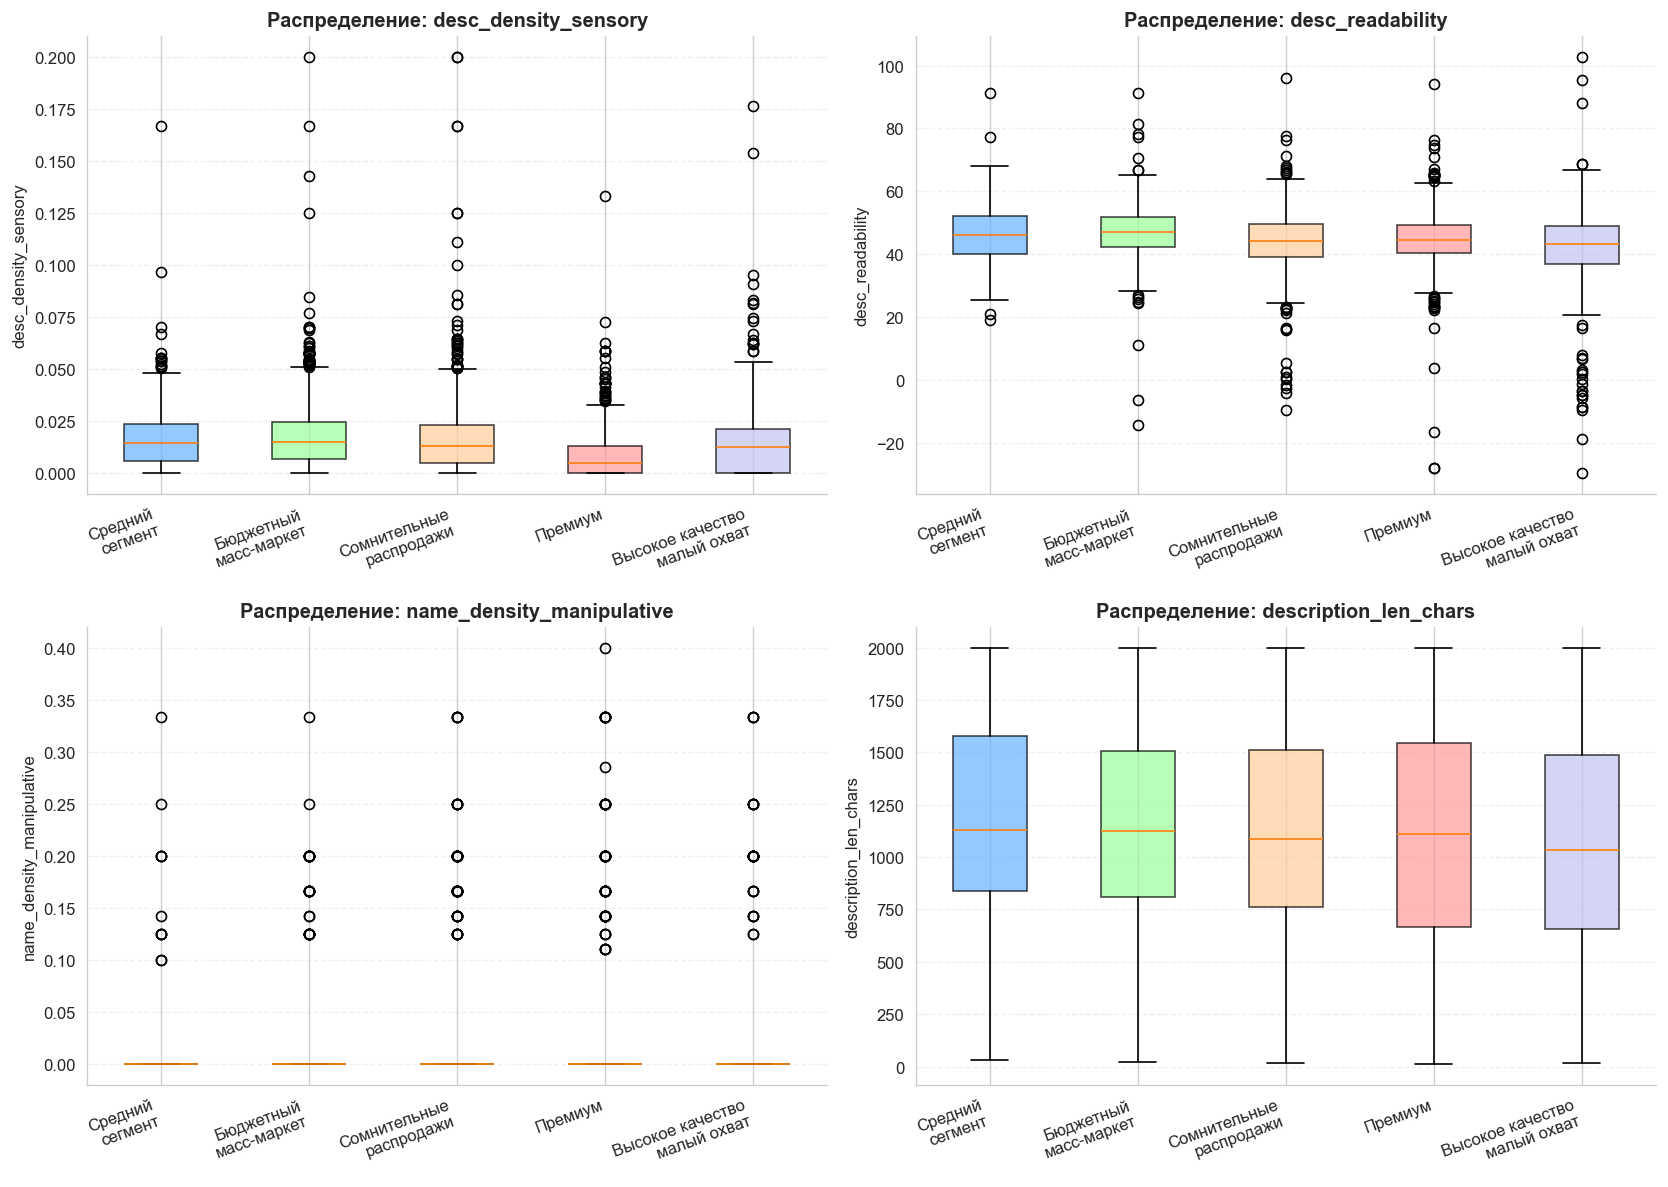

In [10]:
# Визуализация ключевых NLP-признаков по 5 кластерам
key_features = ['desc_density_sensory', 'desc_readability', 'name_density_manipulative', 'description_len_chars']
# Берём только те, что есть
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cluster_labels = ['Средний\nсегмент', 'Бюджетный\nмасс-маркет', 'Сомнительные\nраспродажи', 'Премиум', 'Высокое качество\nмалый охват']

# Получаем уникальные значения кластеров и преобразуем их в целые числа
unique_clusters = sorted([int(c) for c in df['cluster'].dropna().unique()])

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    data_to_plot = []
    positions = []
    for cluster_id in unique_clusters:
        cluster_data = df[df['cluster'] == cluster_id][feature].dropna()
        if len(cluster_data) > 0:
            data_to_plot.append(cluster_data)
            positions.append(cluster_labels[cluster_id])
    
    bp = ax.boxplot(data_to_plot, labels=positions, patch_artist=True)
    colors = ['#66B2FF', '#99FF99', '#FFCC99', '#FF9999', '#C2C2F0'][:len(data_to_plot)]
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
        box.set_alpha(0.7)
    ax.set_title(f'Распределение: {feature}', fontsize=12, fontweight='bold')
    ax.set_ylabel(feature)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_xticklabels(positions, rotation=20, ha='right')

# Если меньше 4 графиков, скроем лишние
for idx in range(len(key_features), 4):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

На основе анализа формулируем более конкретные стратегии для продавцов.

Кластер 0 — Средний сегмент (2129 руб., скидка 44%)
Читаемость — главный фактор. Описания должны быть максимально понятными. Сенсорная лексика умеренно полезна. Длина описания — средняя, не перегружать. Стратегия: «понятно и убедительно».

Кластер 1 — Бюджетный масс-маркет (1693 руб., скидка 71%)
Сенсорная лексика — мощнейший инструмент. Используйте слова: мягкий, нежный, хрустящий, ароматный, гладкий. Манипуляции в заголовке не нужны. Длинные описания не обязательны. Стратегия: «дешево и приятно».

Кластер 2 — Сомнительные распродажи (1792 руб., скидка 75%, низкий рейтинг)
Главная проблема: огромные скидки + плохие описания = низкое качество. Что делать: улучшить читаемость, убрать манипуляции из заголовка, добавить сенсорной лексики. Без изменений текста высокая скидка не спасёт.

Кластер 3 — Премиум (5306 руб., скидка 58%)
Детальные, длинные описания. Статусная лексика (премиум, эксклюзив, дизайнерский). Сенсорная лексика почти не нужна. Скидки есть, но они не главное. Стратегия: «качество и статус».

Кластер 4 — Высокое качество, малый охват (2061 руб., скидка 72%, рейтинг 4.94)
Отличный рейтинг, но низкая востребованность. Товары нишевые. Что делать: не гнаться за массовым покупателем. Улучшить описания, добавить конкретики. Стратегия: «качество для своих».


Кластеризация выделила пять стратегически разных сегментов. Самый успешный по рейтингу — кластер 4 (4.94), но он нишевый. Самый массовый и востребованный — кластер 1 (1108 товаров). Самый проблемный — кластер 2 (низкий рейтинг и востребованность).

Продавцу критически важно:
1. Определить свой сегмент по цене и скидке
2. Адаптировать язык карточки под этот сегмент
3. Универсальные тексты работают хуже целевых

In [11]:
# Финальная сводная таблица: центры кластеров + ключевые NLP-признаки
final_summary = centers_df.copy()
final_summary['cluster_name'] = ['Средний сегмент', 'Бюджетный масс-маркет', 'Сомнительные распродажи', 'Премиум', 'Высокое качество, малый охват']

# Добавим средние значения ключевых NLP-признаков
key_features = ['desc_density_sensory', 'desc_readability', 'name_density_manipulative', 'description_len_chars']
for feature in key_features:
    if feature in df.columns:
        feature_means = []
        for cluster_id in range(5):
            mean_val = df[df['cluster'] == cluster_id][feature].mean()
            feature_means.append(round(mean_val, 4))
        final_summary[feature] = feature_means

print("Финальная сводка по кластерам (для презентации):")
print(final_summary.round(2).to_string())

Финальная сводка по кластерам (для презентации):
   price_winsorized  discount_pct_winsorized  rating_winsorized  popularity  cluster                   cluster_name  desc_density_sensory  desc_readability  name_density_manipulative  description_len_chars
0           2128.96                    44.01               4.81       36.23        0                Средний сегмент                  0.02             46.20                       0.00                1160.70
1           1693.09                    70.63               4.84       41.86        1          Бюджетный масс-маркет                  0.02             46.89                       0.00                1159.31
2           1792.34                    75.26               4.73       24.83        2        Сомнительные распродажи                  0.02             44.08                       0.01                1119.34
3           5306.40                    57.71               4.80       23.62        3                        Премиум            